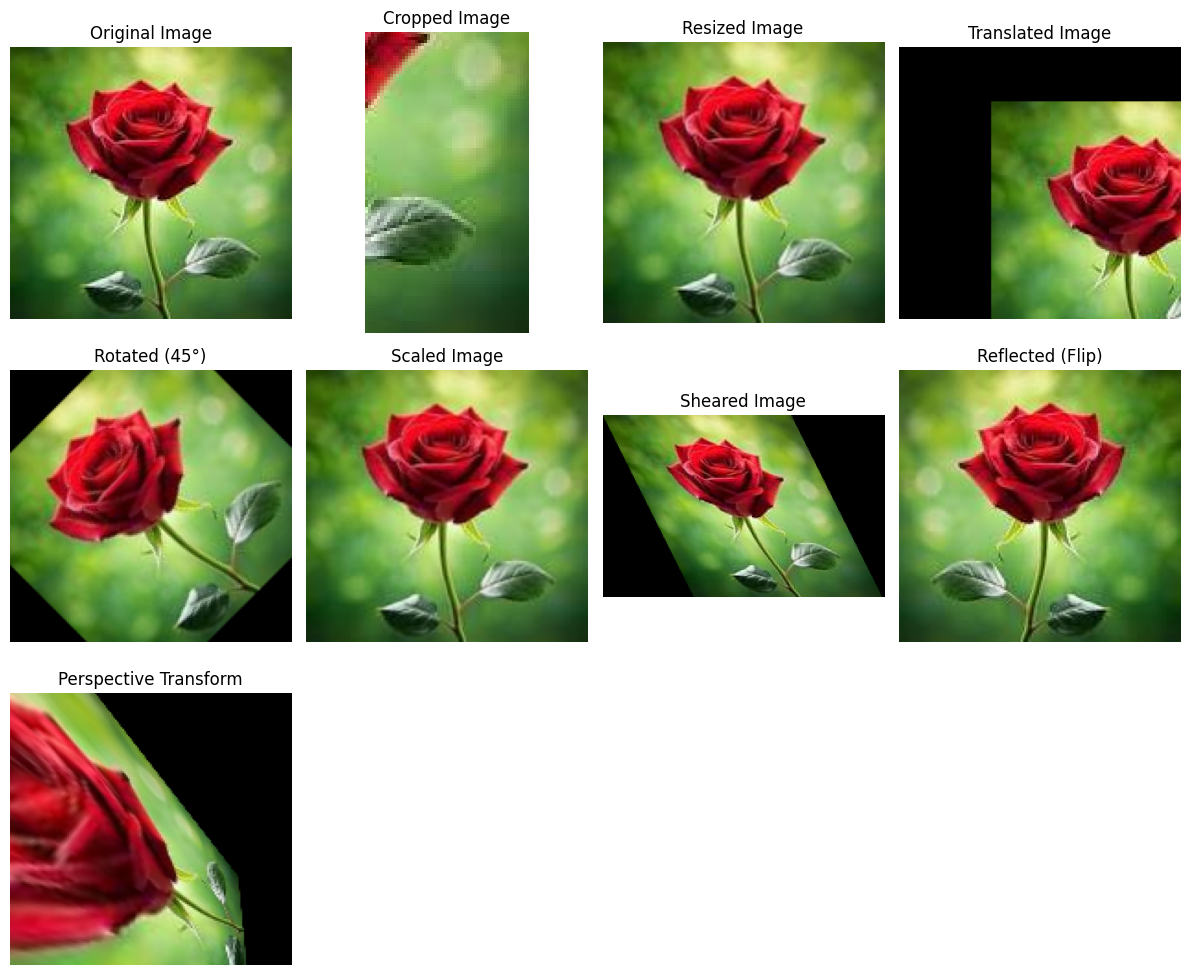

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Read and Display Image
# -----------------------------
img = cv2.imread("download.jpg")
assert img is not None, "Image not found! Check the path."

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure("Image Transformations", figsize=(12, 10))

plt.subplot(3, 4, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

# -----------------------------
# 2. Cropping
# -----------------------------
cropped = img[50:300, 100:400]
cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 2)
plt.imshow(cropped_rgb)
plt.title("Cropped Image")
plt.axis("off")

# -----------------------------
# 3. Resizing
# -----------------------------
resized = cv2.resize(img, (300, 300))
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 3)
plt.imshow(resized_rgb)
plt.title("Resized Image")
plt.axis("off")

# -----------------------------
# 4. Translation
# -----------------------------
rows, cols = img.shape[:2]

M_trans = np.float32([
    [1, 0, 50],
    [0, 1, 30]
])

translated = cv2.warpAffine(img, M_trans, (cols, rows))
translated_rgb = cv2.cvtColor(translated, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 4)
plt.imshow(translated_rgb)
plt.title("Translated Image")
plt.axis("off")

# -----------------------------
# 5. Rotation
# -----------------------------
center = (cols // 2, rows // 2)
M_rot = cv2.getRotationMatrix2D(center, 45, 1.0)

rotated = cv2.warpAffine(img, M_rot, (cols, rows))
rotated_rgb = cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 5)
plt.imshow(rotated_rgb)
plt.title("Rotated (45°)")
plt.axis("off")

# -----------------------------
# 6. Scaling
# -----------------------------
scaled = cv2.resize(img, None, fx=1.5, fy=1.5)
scaled_rgb = cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 6)
plt.imshow(scaled_rgb)
plt.title("Scaled Image")
plt.axis("off")

# -----------------------------
# 7. Shearing
# -----------------------------
M_shear = np.float32([
    [1, 0.5, 0],
    [0, 1, 0]
])

sheared = cv2.warpAffine(img, M_shear, (int(cols * 1.5), rows))
sheared_rgb = cv2.cvtColor(sheared, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 7)
plt.imshow(sheared_rgb)
plt.title("Sheared Image")
plt.axis("off")

# -----------------------------
# 8. Reflection (Flip)
# -----------------------------
flipped = cv2.flip(img, 1)
flipped_rgb = cv2.cvtColor(flipped, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 8)
plt.imshow(flipped_rgb)
plt.title("Reflected (Flip)")
plt.axis("off")

# -----------------------------
# 9. Perspective Transformation
# -----------------------------
pts1 = np.float32([
    [50, 50],
    [cols - 50, 50],
    [50, rows - 50],
    [cols - 50, rows - 50]
])

pts2 = np.float32([
    [10, 100],
    [cols - 100, 50],
    [100, rows - 10],
    [cols - 50, rows - 50]
])

M_persp = cv2.getPerspectiveTransform(pts1, pts2)
perspective = cv2.warpPerspective(img, M_persp, (cols, rows))
perspective_rgb = cv2.cvtColor(perspective, cv2.COLOR_BGR2RGB)

plt.subplot(3, 4, 9)
plt.imshow(perspective_rgb)
plt.title("Perspective Transform")
plt.axis("off")

plt.tight_layout()
plt.show()
